# 4D Regret Landscape of 2x2 General-Sum Games
This notebook visualizes the regret landscape of 2x2 games using three distinct methods:
1. Statistical Marginalization (4-Graph Summary)
2. Interactive Sliders ("Morphing Mountain")
3. Random Orthogonal Slices (Neural Network Landscape Method)

We utilize the ultra-fast out-of-loop PyTorch Dynamo batching mechanism to evaluate thousands of games instantly.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

from src.config.schemas import ExperimentConfig, DynamicConfig, ExecutionConfig, GameConfig
from src.engine.runner import ExperimentRunner

# Constants
TOTAL_STEPS = 200000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Unified Grid Resolution Parameter
GRID_STEPS = 50  # Note: A grid of 10 creates 10,000 games in Task 1!

EVAL_BATCH_SIZE = 200000

print(f"Using device: {DEVICE}")

# Initialize a dummy runner out of the loop
dummy_config = ExperimentConfig(
    name="landscape_eval",
    game=GameConfig(generator="custom"), # Force custom instantiation
    dynamic=DynamicConfig(algorithm="dmwu"), # Uses default eta=0.0625 automatically!
    execution=ExecutionConfig(
        total_steps=TOTAL_STEPS,
        steps_per_call=200,
        device=str(DEVICE),
        dtype="float64",
        batch_size=EVAL_BATCH_SIZE,
        compile=True,
        quiet=True
    )
)
dummy_u1 = torch.zeros((EVAL_BATCH_SIZE, 2, 2), dtype=torch.float64, device=DEVICE)
dummy_u2 = torch.zeros((EVAL_BATCH_SIZE, 2, 2), dtype=torch.float64, device=DEVICE)

dummy_config.game.payoffs = [dummy_u1, dummy_u2]



Using device: cuda


## Task 1: Statistical Marginalization (4-Graph Summary)
Evaluates the 4D grid and marginalizes over variables `c` and `d` to show the statistics of the landscape as a function of `a` and `b`.

Loading cached tensor from dmwu_regrets_tensor_4d_50.pt...


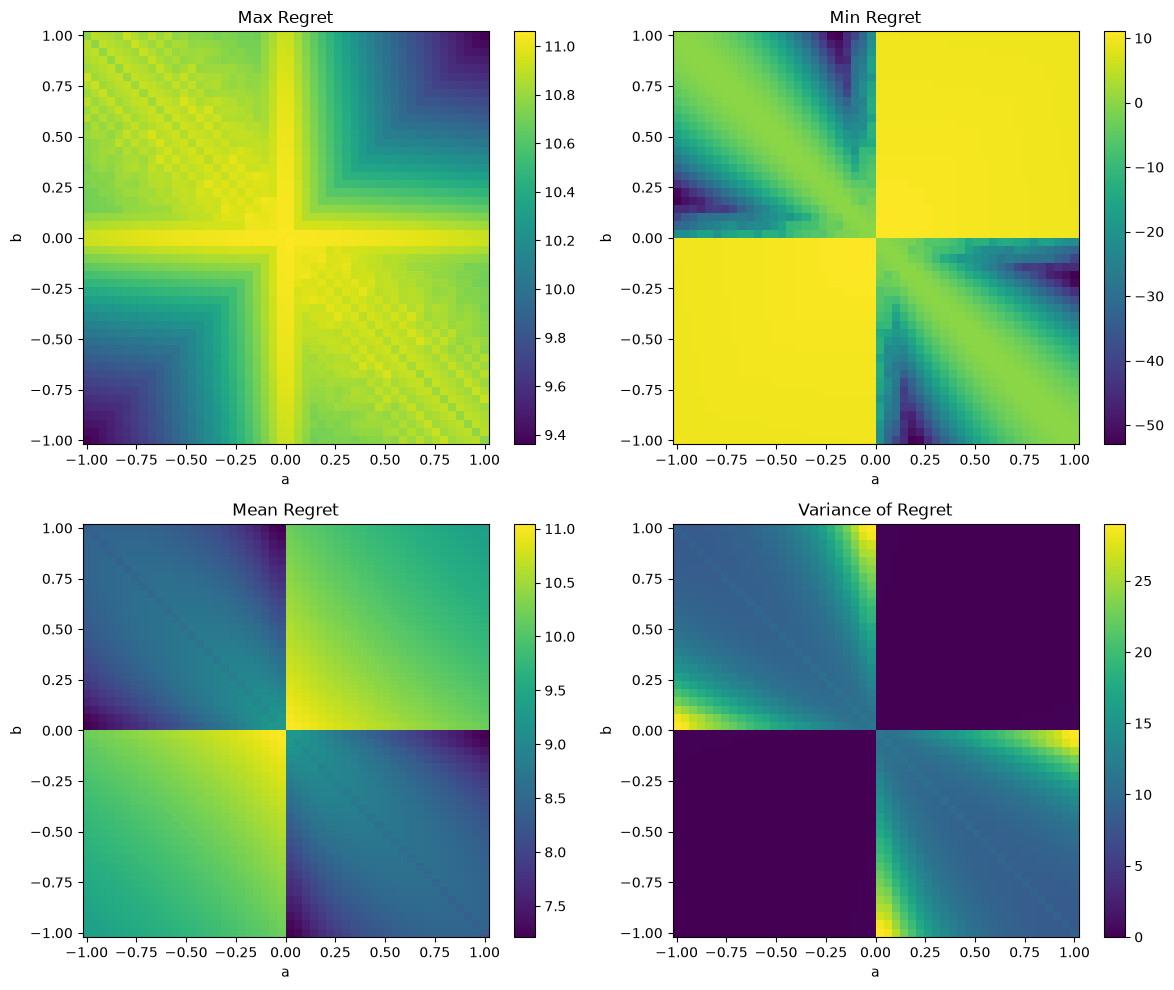

In [2]:
import os

a_vals = torch.linspace(-1, 1, steps=GRID_STEPS)
b_vals = torch.linspace(-1, 1, steps=GRID_STEPS)
c_vals = torch.linspace(-1, 1, steps=GRID_STEPS)
d_vals = torch.linspace(-1, 1, steps=GRID_STEPS)

cache_file = f"dmwu_regrets_tensor_4d_{GRID_STEPS}.pt"

if os.path.exists(cache_file):
    print(f"Loading cached tensor from {cache_file}...")
    regrets_tensor = torch.load(cache_file, weights_only=True)
else:
    print("Initializing global ExperimentRunner (compiling CUDAGraph...)")
    runner = ExperimentRunner(dummy_config)

    # Run once to trigger torch.compile
    _ = runner.run(target_steps=10)
    print("Runner initialized!")

    def evaluate_games_batched(U1_batch: torch.Tensor, U2_batch: torch.Tensor, total_games: int):
        """
        Evaluates an arbitrarily large batch of games safely by chunking them into sizes of EVAL_BATCH_SIZE.
        It automatically pads the last chunk to preserve the PyTorch CUDAGraph cache and concatenates the results.
        """
        all_regrets = []

        # Disable tqdm for tiny batches (like interactive sliders) to reduce console spam
        disable_tqdm = total_games <= EVAL_BATCH_SIZE

        for i in tqdm(range(0, total_games, EVAL_BATCH_SIZE), disable=disable_tqdm, desc="Evaluating Chunks"):
            chunk_end = min(i + EVAL_BATCH_SIZE, total_games)
            current_chunk_size = chunk_end - i

            U1_chunk = U1_batch[i:chunk_end]
            U2_chunk = U2_batch[i:chunk_end]

            # Pad to exact EVAL_BATCH_SIZE to avoid recompilation
            if current_chunk_size < EVAL_BATCH_SIZE:
                pad_size = EVAL_BATCH_SIZE - current_chunk_size
                U1_padded = torch.cat([U1_chunk, U1_chunk[:1].expand(pad_size, -1, -1)])
                U2_padded = torch.cat([U2_chunk, U2_chunk[:1].expand(pad_size, -1, -1)])
            else:
                U1_padded = U1_chunk
                U2_padded = U2_chunk

            runner.reset()
            runner.game.update_payoffs([U1_padded, U2_padded])

            # Run simulation
            metrics = runner.run(target_steps=TOTAL_STEPS)

            # Extract regrets and slice away the padding
            final_regrets = metrics["final_cum_regrets"]
            p1_regrets = final_regrets[0][:current_chunk_size] # Player 1 regrets
            all_regrets.extend(p1_regrets)

        return all_regrets

    print(f"Evaluating 4D Grid ({GRID_STEPS**4} games)...")
    grid_a, grid_b, grid_c, grid_d = torch.meshgrid(a_vals, b_vals, c_vals, d_vals, indexing='ij')

    # Flatten to combinations
    a_flat = grid_a.flatten()
    b_flat = grid_b.flatten()
    c_flat = grid_c.flatten()
    d_flat = grid_d.flatten()

    num_games = len(a_flat)
    U1_batch = torch.zeros((num_games, 2, 2), dtype=torch.float64, device=DEVICE)
    U2_batch = torch.zeros((num_games, 2, 2), dtype=torch.float64, device=DEVICE)

    # Note: The prompt restricts to U1 = [[a, b], [0, 0]] and U2 = [[c, 0], [d, 0]]
    U1_batch[:, 0, 0] = a_flat.to(DEVICE)
    U1_batch[:, 0, 1] = b_flat.to(DEVICE)
    U2_batch[:, 0, 0] = c_flat.to(DEVICE)
    U2_batch[:, 1, 0] = d_flat.to(DEVICE)

    # Evaluate all games safely through the chunking wrapper!
    regrets_flat = evaluate_games_batched(U1_batch, U2_batch, num_games)
    regrets_tensor = torch.tensor(regrets_flat).reshape(GRID_STEPS, GRID_STEPS, GRID_STEPS, GRID_STEPS)
    
    print(f"Saving tensor to {cache_file}...")
    torch.save(regrets_tensor, cache_file)

# Marginalize over c and d (dims 2 and 3)
max_reg = regrets_tensor.max(dim=3).values.max(dim=2).values.numpy()
min_reg = regrets_tensor.min(dim=3).values.min(dim=2).values.numpy()
mean_reg = regrets_tensor.mean(dim=(2, 3)).numpy()
var_reg = regrets_tensor.var(dim=(2, 3)).numpy()

# Plot 2x2 Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
A_grid, B_grid = np.meshgrid(a_vals.numpy(), b_vals.numpy(), indexing='ij')

metrics = [
    ("Max Regret", max_reg, axes[0, 0]), 
    ("Min Regret", min_reg, axes[0, 1]), 
    ("Mean Regret", mean_reg, axes[1, 0]), 
    ("Variance of Regret", var_reg, axes[1, 1])
]

for title, data, ax in metrics:
    c = ax.pcolormesh(A_grid, B_grid, data, shading='auto', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel("a")
    ax.set_ylabel("b")
    fig.colorbar(c, ax=ax)

plt.tight_layout()
plt.show()

## Task 2: Interactive Sliders ("Morphing Mountain")
Drag the sliders for `c` and `d` to interactively warp the 3D regret landscape in real-time! 

*Note: This cell evaluates the exact real values dynamically through the PyTorch simulation batcher, bypassing any interpolation!*

In [3]:
# Extract meshgrid directly from Task 1 variables for c and d axes
C_np, D_np = np.meshgrid(c_vals.numpy(), d_vals.numpy(), indexing='ij')

# Find the global maximum regret across the entire 4D space to lock the Z-axis
global_max_z = regrets_tensor.max().item()

def plot_morphing_mountain(a_idx, b_idx):
    # Slice the exact pre-computed tensor from Task 1 instantly
    regrets_grid = regrets_tensor[a_idx, b_idx, :, :].numpy()
    
    # Retrieve true floating values for display
    a_val = a_vals[a_idx].item()
    b_val = b_vals[b_idx].item()
    
    # Plot 3D surface
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(C_np, D_np, regrets_grid, cmap='magma', edgecolor='none')
    
    ax.set_title(f"Regret Landscape given a={a_val:.2f}, b={b_val:.2f}")
    ax.set_xlabel("c")
    ax.set_ylabel("d")
    ax.set_zlabel("Cumulative Regret")
    ax.set_zlim(0, max(1.0, global_max_z * 1.05)) # Keep z-axis perfectly stable
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    plt.show()

# Create interactive widget using integer indices to snap perfectly to the grid
interact(plot_morphing_mountain, 
         a_idx=widgets.IntSlider(min=0, max=GRID_STEPS-1, step=1, value=GRID_STEPS//2, description='a index'),
         b_idx=widgets.IntSlider(min=0, max=GRID_STEPS-1, step=1, value=GRID_STEPS//2, description='b index'))

interactive(children=(IntSlider(value=25, description='a index', max=49), IntSlider(value=25, description='b i…

<function __main__.plot_morphing_mountain(a_idx, b_idx)>